# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import boto3
import s3fs
import matplotlib.pyplot as plt
import seaborn as sns
# Weather data library
from meteostat import Stations, Daily
from datetime import datetime
from pyathena import connect
import warnings
warnings.filterwarnings("ignore")

# Connect SageMaker to S3

In [2]:
#Create S3 client using boto3
#This allows the notebook to communicate with S3
s3 = boto3.client('s3')

#Define your S3 bucket name where your datasets are stored
bucket = "vegetation-risk-ml"

#list files inside bucket
response = s3.list_objects_v2(Bucket=bucket)

#Print the names of the files in the bucket
for obj in response['Contents']:
    print(obj['Key'])

processed/
raw/
raw/fire/
raw/fire/California_Historic_Fire_data.csv
raw/forest/
raw/forest/CA_SUBPLOT.csv
raw/forest/CA_TREE.csv
raw/forest/CA_TREE_REGIONAL_BIOMASS.csv
raw/weather/


The datasets used in this project were originally downloaded from public government data sources- the U.S. Forest Service (FIA), CAL FIRE wildfire records and NOAA weather data accessed through the Meteostat library. After downloading, the files were manually uploaded to an Amazon S3 bucket. The datasets are accessed from Amazon S3 using SageMaker Studio notebooks for exploration and further processing.

# Load FIA(forest vegetation data) from S3

The FIA forest vegetation dataset consists of three tables: subplot information, tree characteristics, and biomass measurements. These files are stored in Amazon S3 and loaded into the SageMaker notebook for further analysis. 

In [3]:
#file path for FIA forest datasets inside S3 bucket
subplot_path = "s3://vegetation-risk-ml/raw/forest/CA_SUBPLOT.csv"
tree_path = "s3://vegetation-risk-ml/raw/forest/CA_TREE.csv"
biomass_path = "s3://vegetation-risk-ml/raw/forest/CA_TREE_REGIONAL_BIOMASS.csv"

In [4]:
# Load the CSV file from S3 into a pandas DataFrame
subplot = pd.read_csv(subplot_path, low_memory=False)
subplot.head(3)

,CN,PLT_CN,PREV_SBP_CN,INVYR,STATECD,UNITCD,COUNTYCD,PLOT,SUBP,SUBP_STATUS_CD,...,GROUND_TRAN_PTS_OTHER_RMRS,GROUND_TRAN_PTS_PEIS_RMRS,GROUND_TRAN_PTS_ROAD_RMRS,GROUND_TRAN_PTS_ROCK_RMRS,GROUND_TRAN_PTS_TRIS_RMRS,GROUND_TRAN_PTS_VEG_RMRS,GROUND_TRAN_PTS_WATER_RMRS,GROUND_TRAN_PTS_WOOD_RMRS,PREV_STATUSCD_RMRS,ROOTSEVCD_RMRS
0,59015,11839,NaN,1994,6,1,15,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59042,11839,NaN,1994,6,1,15,1,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,59068,11839,NaN,1994,6,1,15,1,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Load the tree dataset from the specified file path into a pandas DataFrame.
trees = pd.read_csv(tree_path, low_memory=False)
trees.head(3)

,CN,PLT_CN,PREV_TRE_CN,INVYR,STATECD,UNITCD,COUNTYCD,PLOT,SUBP,TREE,...,DRYBIO_STUMP_BARK,DRYBIO_BOLE_BARK,DRYBIO_BRANCH,DRYBIO_FOLIAGE,DRYBIO_SAWLOG_BARK,PREV_ACTUALHT_FLD,PREV_HT_FLD,UTILCLCD,SPCD_ID_CD,ABNORMAL_TERMINATION
0,675267,11839,NaN,1994,6,1,15,1,1,675267,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,675268,11839,NaN,1994,6,1,15,1,1,675268,...,17.718832,469.383932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,675269,11839,NaN,1994,6,1,15,1,1,675269,...,10.354492,143.559569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Load the biomass dataset from the specified file path into a pandas DataFrame
biomass = pd.read_csv(biomass_path, low_memory=False)
biomass.head(3)

,TRE_CN,STATECD,REGIONAL_DRYBIOT,REGIONAL_DRYBIOM,CREATED_BY,CREATED_DATE,CREATED_IN_INSTANCE,MODIFIED_BY,MODIFIED_DATE,MODIFIED_IN_INSTANCE,REGIONAL_DRYBIOSL
0,44784050020004,6,181.351518,94.186487,RWANEK,2012-07-26 14:10:00,20004,FSJASONBROWN,2020-07-11 23:46:37,290487,NaN
1,44784051020004,6,244.463259,167.318417,RWANEK,2012-07-26 14:10:00,20004,FSJASONBROWN,2020-07-11 23:46:37,290487,152.313767
2,44784052020004,6,356.127994,204.940133,RWANEK,2012-07-26 14:10:00,20004,FSJASONBROWN,2020-07-11 23:46:37,290487,187.352578


In [7]:
#check data structure of subplot dataset
subplot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178917 entries, 0 to 178916
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CN                             178917 non-null  int64  
 1   PLT_CN                         178917 non-null  int64  
 2   PREV_SBP_CN                    3384 non-null    float64
 3   INVYR                          178917 non-null  int64  
 4   STATECD                        178917 non-null  int64  
 5   UNITCD                         178917 non-null  int64  
 6   COUNTYCD                       178917 non-null  int64  
 7   PLOT                           178917 non-null  int64  
 8   SUBP                           178917 non-null  int64  
 9   SUBP_STATUS_CD                 178917 non-null  int64  
 10  POINT_NONSAMPLE_REASN_CD       9005 non-null    float64
 11  MICRCOND                       155600 non-null  float64
 12  SUBPCOND                      

In [8]:
#check data structure of tree dataset
trees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446320 entries, 0 to 446319
Columns: 198 entries, CN to ABNORMAL_TERMINATION
dtypes: float64(181), int64(13), object(4)
memory usage: 674.2+ MB


In [9]:
#check data structure of biomass dataset
biomass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390955 entries, 0 to 390954
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TRE_CN                390955 non-null  int64  
 1   STATECD               390955 non-null  int64  
 2   REGIONAL_DRYBIOT      316455 non-null  float64
 3   REGIONAL_DRYBIOM      329615 non-null  float64
 4   CREATED_BY            390955 non-null  object 
 5   CREATED_DATE          390955 non-null  object 
 6   CREATED_IN_INSTANCE   390955 non-null  int64  
 7   MODIFIED_BY           390955 non-null  object 
 8   MODIFIED_DATE         390955 non-null  object 
 9   MODIFIED_IN_INSTANCE  390955 non-null  int64  
 10  REGIONAL_DRYBIOSL     137020 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 32.8+ MB


#### Merge tree,biomass and subplot dataset

In [10]:
#Merge trees and subplot.To save memory, we will choose needed columns only
combined_forest = trees[["CN", "PLT_CN", "DIA", "HT", "SPCD", "STATUSCD"]].merge(subplot[["PLT_CN", "SLOPE", "ASPECT"]],on="PLT_CN",how="left")

#Merge the resulting dataframe with biomass dataframe on tree identifier.Again, select needed columns to save memory
combined_forest = combined_forest.merge(biomass[["TRE_CN", "REGIONAL_DRYBIOT", "REGIONAL_DRYBIOM"]],left_on="CN",right_on="TRE_CN",how="left")
combined_forest = combined_forest.drop_duplicates()

#Check the resulting dataframe
print("Merged forest dataset shape:", combined_forest.shape)
combined_forest.head()

Merged forest dataset shape: (1687167, 11)


,CN,PLT_CN,DIA,HT,SPCD,STATUSCD,SLOPE,ASPECT,TRE_CN,REGIONAL_DRYBIOT,REGIONAL_DRYBIOM
0,675267,11839,3.9,43.0,631.0,1,50.0,225.0,675267.0,NaN,0.000000
2,675267,11839,3.9,43.0,631.0,1,60.0,225.0,675267.0,NaN,0.000000
4,675267,11839,3.9,43.0,631.0,1,40.0,180.0,675267.0,NaN,0.000000
5,675268,11839,24.1,95.0,202.0,1,50.0,225.0,675268.0,NaN,2835.999965
7,675268,11839,24.1,95.0,202.0,1,60.0,225.0,675268.0,NaN,2835.999965


The three FIA datasets are merged to create a unified forest vegetation dataset. The merge connects tree measurements with subplot environmental characteristics and biomass estimates.

In [11]:
#Save this merged dataframe to S3 for future use
combined_forest.to_csv("s3://vegetation-risk-ml/processed/forest/combined_forest_data.csv", index=False)

# Load CALFIRE dataset from S3

The CAL FIRE dataset contains wildfire perimeter records for California, originaly downloaded from public website and uploaded manully into S3 in raw/fire folder.This dataset provides information on fire location, cause, start date, and burned area.

In [12]:
# Path to wildfire dataset stored in S3
fire_path = "s3://vegetation-risk-ml/raw/fire/California_Historic_Fire_data.csv"

# Load wildfire dataset
fire = pd.read_csv(fire_path)

# Display dataset shape and rows
print("Fire dataset shape:", fire.shape)
fire.head(3)

Fire dataset shape: (3372, 23)


,incident_name,incident_is_final,incident_date_last_update,incident_date_created,incident_administrative_unit,incident_administrative_unit_url,incident_county,incident_location,incident_acres_burned,incident_containment,...,incident_latitude,incident_type,incident_id,incident_url,incident_date_extinguished,incident_dateonly_extinguished,incident_dateonly_created,is_active,calfire_incident,notification_desired
0,Bridge Fire,Y,2018-01-09T13:46:00Z,2017-10-31T11:22:00Z,Shasta-Trinity National Forest,NaN,Shasta,"I-5 and Turntable Bay, 7 miles NE of Shasta Lake",37.0,100.0,...,40.774000,NaN,2ca11d45-8139-4c16-8af0-880d99b21e82,https://www.fire.ca.gov/incidents/2017/10/31/b...,2018-01-09T13:46:00Z,2018-01-09,2017-10-31,N,False,False
1,Pala Fire,Y,2020-09-16T14:07:35Z,2009-05-24T14:56:00Z,CAL FIRE San Diego Unit,NaN,San Diego,"Hwy 76 and Pala Temecula, northwest of Pala",122.0,100.0,...,1.000000,Wildfire,8f61f461-552d-4538-b186-35ab030da416,https://www.fire.ca.gov/incidents/2009/5/24/pa...,2009-05-25T00:00:00Z,2009-05-25,2009-05-24,N,True,False
2,River Fire,Y,2022-10-24T11:39:23Z,2013-02-24T08:16:00Z,CAL FIRE San Bernardino Unit,NaN,Inyo,"south of Narrow Gauge Rd & north of Hwy 136, e...",407.0,100.0,...,36.602575,NaN,094719ba-a47b-4abb-9ec5-a506b2b9fd23,https://www.fire.ca.gov/incidents/2013/2/24/ri...,2013-02-28T20:00:00Z,2013-02-28,2013-02-24,N,True,False


In [13]:
#Basic structure of fire dataset
print(fire.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3372 entries, 0 to 3371
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   incident_name                     3372 non-null   object 
 1   incident_is_final                 3372 non-null   object 
 2   incident_date_last_update         3372 non-null   object 
 3   incident_date_created             3372 non-null   object 
 4   incident_administrative_unit      3307 non-null   object 
 5   incident_administrative_unit_url  0 non-null      float64
 6   incident_county                   3362 non-null   object 
 7   incident_location                 3372 non-null   object 
 8   incident_acres_burned             3319 non-null   float64
 9   incident_containment              3320 non-null   float64
 10  incident_control                  119 non-null    object 
 11  incident_cooperating_agencies     1691 non-null   object 
 12  incide

In [14]:
#missing values in fire dataset
print(fire.isnull().sum())

incident_name                          0
incident_is_final                      0
incident_date_last_update              0
incident_date_created                  0
incident_administrative_unit          65
incident_administrative_unit_url    3372
incident_county                       10
incident_location                      0
incident_acres_burned                 53
incident_containment                  52
incident_control                    3253
incident_cooperating_agencies       1681
incident_longitude                     0
incident_latitude                      0
incident_type                       1234
incident_id                            0
incident_url                           0
incident_date_extinguished           741
incident_dateonly_extinguished       741
incident_dateonly_created              0
is_active                              0
calfire_incident                       0
notification_desired                   0
dtype: int64


In [15]:
#duplicated values in fire dataset
print(fire.duplicated().sum())

0


# Load Weather Data Using Meteostat

Weather stations across California are retrieved using the Meteostat API. These stations provide historical weather measurements such as temperature and precipitation.

In [16]:
# Retrieve weather stations located in California
stations = Stations()

stations = stations.region('US', 'CA')
stations = stations.fetch(100)

print(stations.head())

# download weather data
start = datetime(2015,1,1)
end = datetime(2026,1,1)

weather_data = []

for station_id in stations.index[:50]:
    
    try:
        data = Daily(station_id, start, end).fetch()
        data["station"] = station_id
        weather_data.append(data)
        
    except:
        pass

weather = pd.concat(weather_data)

weather.reset_index(inplace=True)

weather.head()

                                     name country region    wmo  icao  \
id                                                                      
69002      Hunter Ligget / Hunter-Liggett      US     CA  69002  KHGT   
69007                   Fort Ord / Blanco      US     CA  69007  KOAR   
69014                              Irvine      US     CA  69014  KNZJ   
69015  Twentynine Palms / Sunfair Heights      US     CA  69015  KNXP   
69542                Monterey / Del Monte      US     CA  69542  KQNM   

       latitude  longitude  elevation             timezone hourly_start  \
id                                                                        
69002   35.9935  -121.2367      310.0  America/Los_Angeles   1964-07-15   
69007   36.6815  -121.7617       42.0  America/Los_Angeles   1973-01-02   
69014   33.6667  -117.7167      119.0  America/Los_Angeles   1989-01-01   
69015   34.2962  -116.1622      625.0  America/Los_Angeles   1990-01-02   
69542   36.5900  -121.8600      152.0 

,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,station
0,2020-11-05,13.5,8.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69007
1,2020-11-06,12.1,8.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69007
2,2020-11-07,9.9,6.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69007
3,2020-11-08,9.1,2.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69007
4,2020-11-09,5.5,-1.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69007


In [17]:
#Summary statistics of weather data
weather.describe()

,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
count,159235,152333.000000,158959.000000,158959.000000,143040.000000,43636.000000,106811.000000,152006.000000,0.0,137446.000000,0.0
mean,2020-08-29 20:22:52.311363840,16.797217,10.503067,22.688162,1.068746,0.051082,236.228759,11.774533,NaN,1015.370383,NaN
min,2015-01-01 00:00:00,-28.700000,-39.000000,-27.800000,0.000000,0.000000,0.000000,0.000000,NaN,977.900000,NaN
25%,2017-12-02 00:00:00,12.100000,6.700000,17.200000,0.000000,0.000000,169.000000,7.600000,NaN,1012.000000,NaN
50%,2020-10-12 00:00:00,15.900000,11.000000,21.700000,0.000000,0.000000,271.000000,10.300000,NaN,1014.900000,NaN
75%,2023-06-05 00:00:00,20.800000,14.800000,27.800000,0.000000,0.000000,319.000000,14.400000,NaN,1018.500000,NaN
max,2026-01-01 00:00:00,43.700000,37.200000,61.000000,907.400000,230.000000,360.000000,125.600000,NaN,1038.500000,NaN
std,NaN,6.858638,7.028203,8.644289,5.661136,2.511425,103.917898,6.514485,NaN,4.901558,NaN


In [18]:
#missing values
print(weather.isnull().sum())

time            0
tavg         6902
tmin          276
tmax          276
prcp        16195
snow       115599
wdir        52424
wspd         7229
wpgt       159235
pres        21789
tsun       159235
station         0
dtype: int64


In [19]:
# save the weather data to S3 for future use
weather.to_csv("s3://vegetation-risk-ml/raw/weather/california_weather_data.csv", index=False)

# INITIAL DATA EXPLORATION

### What are the distributions and relationships among key weather variables (temperature, precipitation, and wind speed) across California?
    

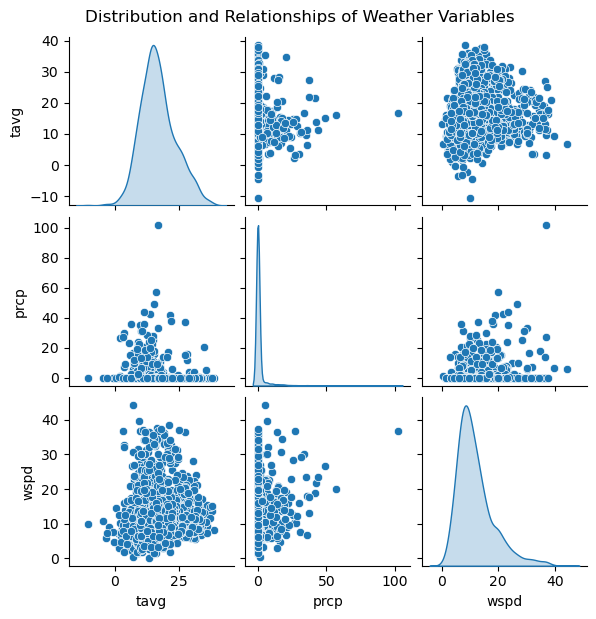

In [20]:

weather_subset = weather[["tavg","prcp","wspd"]]

sns.pairplot(weather_subset.sample(2000),diag_kind="kde", height=2)

plt.suptitle("Distribution and Relationships of Weather Variables", y=1.02)
plt.show()

The pairplot shows the distribution and relationships between temperature, precipitation, and wind speed across California weather stations. Temperature appears approximately normally distributed, while precipitation is heavily right-skewed, indicating that most days have little or no rainfall with occasional heavy precipitation events. Wind speed shows moderate variability but is generally concentrated around lower values. The scatter relationships suggest weak correlations between these variables, indicating that temperature, precipitation, and wind speed vary relatively independently across the dataset.

### Is wildfire size distribution skewed toward extreme events?

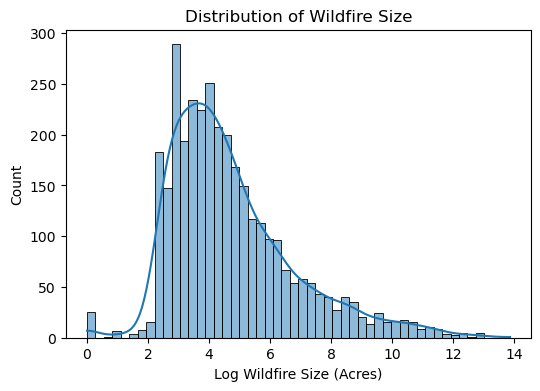

In [21]:
import numpy as np

plt.figure(figsize=(6,4))
sns.histplot(np.log1p(fire["incident_acres_burned"]),kde=True, bins=50)

plt.xlabel("Log Wildfire Size (Acres)")
plt.title("Distribution of Wildfire Size")
plt.show()

Plot shows Wildfire data is right-skewed.Most fires burn small areas, while a small number of large fires account for a significant portion of total burned land. This pattern is common in wildfire datasets and highlights the importance of identifying conditions that lead to extreme fire events.

### What is the distribution of vegetation biomass across forest plots?

This directly uses your forest dataset and helps understand fuel load, which is important for wildfire risk.

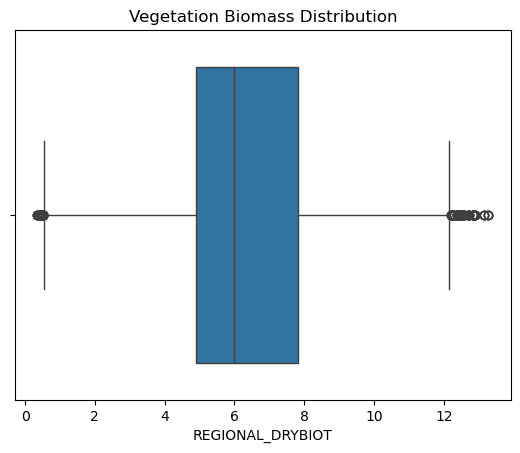

In [22]:
sns.boxplot(x=np.log1p(combined_forest["REGIONAL_DRYBIOT"].dropna()))

plt.title("Vegetation Biomass Distribution")
plt.show()

The vegetation biomass distribution is highly right-skewed, indicating that most forest plots contain relatively low to moderate biomass while a small number of plots have extremely high biomass values. These high-biomass areas may represent dense vegetation and which can act as larger fuel sources and potentially increase wildfire intensity if ignition occurs.

### Where are wildfire incidents geographically concentrated across California?

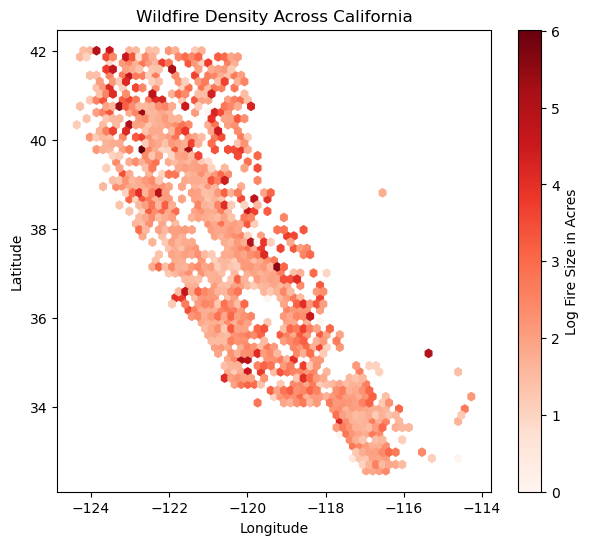

In [28]:
plt.figure(figsize=(7,6))
#remove invalid coordinates
fire_plt = fire[(fire["incident_longitude"].between(-125,-114)) & (fire["incident_latitude"].between(32,42))]
#plot the hexbin
scatter = plt.hexbin(x=fire_plt["incident_longitude"],y=fire_plt["incident_latitude"],C=np.log10(fire_plt["incident_acres_burned"] + 1),gridsize=60,
    cmap="Reds",mincnt=1)
bar = plt.colorbar(scatter)
bar.set_label("Log Fire Size in Acres")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Wildfire Density Across California")
plt.show()

The hexbin plot highlights the geographic density of wildfire incidents across California. Each hexagon represents a geographic area.Areas with darker hexagons represent larger fires, not necessarily more fires. This suggests Northern California shows frequent and large fires, Southern California shows large fires due to dry climate and vegetation fuel loads, and the Central Valley shows fewer fires because the vegetation is lower. Identifying such hotspots can support vegetation management strategies, including prioritizing tree trimming in high-risk regions.

# **DATA PREPARATION**

**Define s3 path**

In [ ]:
#Define S3 fi
forest_path  = "s3://vegetation-risk-ml/processed/forest/combined_forest_data.csv"
fire_path    = "s3://vegetation-risk-ml/raw/fire/California_Historic_Fire_data.csv"
weather_path = "s3://vegetation-risk-ml/raw/weather/california_weather_data.csv"

**Load datasets**

In [ ]:
combined_forest = pd.read_csv(forest_path, low_memory=False)
print("Forest dataset shape :", combined_forest.shape)
fire = pd.read_csv(fire_path, low_memory=False)
print("Fire dataset shape :", fire.shape)
weather = pd.read_csv(weather_path, low_memory=False)
print("Weather dataset shape :", weather.shape)

print("Datasets loaded successfully")

# DATA CLEANING AND PREPROCESSING

### Forest dataset cleaning

We will handle missing values and drop the unnecessary columns so that the dataset represents only relevent columns which directly affects trimming prioritization.This stage will prepare our dataset for integration.

Here only variables that influence vegetation density and wildfire potential are retained.

**Drop unnecessary columns**

 We drop plt_cn,spsd to avoid noise in the data and reduce memory usage.From exploration,we know that REGIONAL_DRYBIOT and REGIONAL_DRYBIOM are highly correlated so we keep only one of them.

In [ ]:
#select most relevent column 
combined_forest=combined_forest[["DIA", "HT", "SLOPE", "ASPECT", "REGIONAL_DRYBIOT"]]  #tree size,height,terrain,direction,biomass

#check the shape of the dataset
combined_forest.shape

**Remove Duplicates**

In [ ]:
#remove duplicates
combined_forest = combined_forest.drop_duplicates()
# Verify
print("Duplicates remaining:", combined_forest.duplicated().sum())

**Handle missing valus**

To handle missing values, median is used because biomass is skewed and avoids distortion from outliers.

In [ ]:
#fill missing values for biomass
combined_forest["REGIONAL_DRYBIOT"] = combined_forest["REGIONAL_DRYBIOT"].fillna(combined_forest["REGIONAL_DRYBIOT"].median())

# Verify
print("Missing values:\n", combined_forest.isnull().sum())

**Handle outlier**

In [ ]:
#handle unrealistic value of tree diameter and height
combined_forest = combined_forest[(combined_forest["DIA"] > 0) & (combined_forest["HT"] > 0)]

In [ ]:
#Verify the resulting dataset
combined_forest.head()

### Fire dataset cleaning

Here we will keep valid geographic coordinates and meaningful fire size measurements only.

**Select Relevent Columns**

In [ ]:
#select relevant features only
fire=fire[["incident_acres_burned", "incident_longitude", "incident_latitude", "incident_date_created","incident_county"]]

In [ ]:
#Remove fires with missing coordinates
fire = fire.dropna(subset=["incident_latitude", "incident_longitude"])

#Remove fires with zero size
fire = fire[fire["incident_acres_burned"] > 0]

#Convert datecolumn to datetime
fire["incident_date_created"] = pd.to_datetime(fire["incident_date_created"], errors="coerce")

#display results
print("Cleaned fire dataset shape:", fire.shape)


In [ ]:
#check for any remaining missing value
fire.isnull().sum()
fire.head()

#### Weather dataset cleaning

We will select temperature ,precipitation and wind speed that influence vegetation growth and fire risk. Here missing values are imputed to ensure consistent weather observations.

In [ ]:
#Select most relevent columns
weather = weather[["time", "tavg", "prcp", "wspd", "station"]]

In [ ]:
# Convert time column
weather["time"] = pd.to_datetime(weather["time"])

# Fill missing rainfall
weather["prcp"] = weather["prcp"].fillna(0)

# Fill wind speed
weather["wspd"] = weather["wspd"].fillna(weather["wspd"].median())

# Remove unrealistic temperatures
weather = weather[(weather["tavg"] > -40) & (weather["tavg"] < 60)]

# Fill missing average temperature
weather["tavg"] = weather["tavg"].fillna((weather["tmin"] + weather["tmax"])/2)


In [ ]:
#Verify the resulting dataset
print("Cleaned weather dataset shape:", weather.shape)
#check for any remaining missing values
print("Missing values in each column:")
print(weather.isnull().sum())
print("First few rows of the cleaned dataset:")
weather.head()

#### **Save the cleaned dataset to S3**

The cleaned datasets are then store back in S3 in separete folder processed/ for future analysis.

In [ ]:
combined_forest.to_csv("s3://vegetation-risk-ml/processed/forest/forest_cleaned.csv",index=False)

fire.to_csv("s3://vegetation-risk-ml/processed/fire/fire_cleaned.csv",index=False)

weather.to_csv("s3://vegetation-risk-ml/processed/weather/weather_cleaned.csv",index=False)

print("Cleaned datasets saved successfully in S3")

Next,to merge all three cleaned datasets, we are using Athena.

Athena is used to perform  data merging of all three cleaned datasets and aggregation directly on S3 without loading large datasets into memory.This resolves the high memory usage and slow processing.The final unified feature table will be used for model training and dashboard visualization.

# Connect SageMaker to Athena

In [ ]:

#Query results are stored in s3 in this directory
s3_staging_dir = "s3://vegetation-risk-ml/athena-results/"

# Athena connection
conn = connect(s3_staging_dir=s3_staging_dir,region_name="us-west-2")

print("Connected to Athena")

# Create Table for Forest Dataset

In [ ]:
CREATE EXTERNAL TABLE IF NOT EXISTS vegetation_ml.forest_cleaned (
DIA DOUBLE,
HT DOUBLE,
SLOPE DOUBLE,
ASPECT DOUBLE,
REGIONAL_DRYBIOT DOUBLE
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
LOCATION 's3://vegetation-risk-ml/processed/forest/';

# Create Table for Weather Dataset

In [ ]:
CREATE EXTERNAL TABLE IF NOT EXISTS vegetation_ml.weather_cleaned (
time TIMESTAMP,
tavg DOUBLE,
prcp DOUBLE,
wspd DOUBLE,
station STRING,
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
LOCATION 's3://vegetation-risk-ml/processed/weather/';

# Create Table for Fire Dataset

In [ ]:
CREATE EXTERNAL TABLE IF NOT EXISTS vegetation_ml.fire_cleaned (
incident_acres_burned DOUBLE,
incident_longitude DOUBLE,
incident_latitude DOUBLE,
incident_date_created TIMESTAMP,
incident_county STRING,
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
LOCATION 's3://vegetation-risk-ml/processed/fire/';

**Verify tables**

In [ ]:

# Check if tables exist and data is accessible
for table in ["forest_cleaned", "weather_cleaned", "fire_cleaned"]:
    query = f"SELECT * FROM vegetation_ml.{table} LIMIT 5"
    df = pd.read_sql(query, conn)
    print(f"Sample data from {table}:")
    print(df.head())
    print("\n")

# Create Unified Feature table in Athena

Now we create the final Feature table by merging all three tables. This final table becomes the single source of truth for modelling and dashboard analysis.

In [ ]:
CREATE TABLE vegetation_ml.vegetation_risk_dataset WITH (format='PARQUET',external_location='s3://vegetation-risk-ml/final/') AS
SELECT
    f.DIA,              #Tree diameter
    f.HT,               #Tree height
    f.SLOPE,            #Terrain slope
    f.ASPECT,           #Terrain aspect
    f.REGIONAL_DRYBIOT, #Vegetation biomass

    w.avg_temp,    #Average temperature
    w.avg_rain,    #Average precipitation
    w.avg_wind,

    fi.fire_count,     #Number of fires in the area
    fi.max_fire_size   #Maximum size of fires in the area
    fi.sample_lat,   #Latitude of fire incidents
    fi.sample_lon,   #Longitude of fire incidents
    fi.fire_year          #Year of fire incidents

FROM vegetation_ml.forest_cleaned f

LEFT JOIN    #Aggregate weather data to get average conditions
(
    SELECT
        AVG(tavg) AS avg_temp,
        AVG(prcp) AS avg_rain,
        AVG(wspd) AS avg_wind
    FROM vegetation_ml.weather_cleaned
) w
ON TRUE

LEFT JOIN     #Aggregate time-based fire data to get fire frequency, size and location
(
    SELECT
        incident_county,
        COUNT(*) AS fire_count,
        AVG(incident_acres_burned) AS incident_acres_burned,
        AVG(incident_latitude) AS incident_latitude,
        AVG(incident_longitude) AS incident_longitude,
        MIN(incident_date_created) AS incident_date_created
    FROM vegetation_ml.fire_cleaned
    GROUP BY incident_county
) fi
ON TRUE;

In [ ]:
#verify if table is created and data is populated
query = "SELECT * FROM vegetation_ml.vegetation_risk_dataset LIMIT 5"
vegetation_risk_dataset = pd.read_sql(query, conn)


#Verify the resulting dataset
print(vegetation_risk_dataset.shape)
vegetation_risk_dataset.head()

**Load Final Feature Table from S3 into SageMaker**

The unified feature table (source of truth) created by Athena is loaded from the S3 final/ folder into SageMaker for feature engineering and model training.

In [ ]:
vegetation_risk_data = pd.read_parquet("s3://vegetation-risk-ml/final/")

# **Feature Engineering**

# Feature Creation

Here we will create new features and transform the existing features for our machine learning model.

**Fuel Mositure Risk**

This featutee captures vegetation dryness(hot weather and no rain).The higher value means drier the vegetation condition,which increase wildfire risk if ignition happens. Its calculated as fuel moisture risk=temperatue/(rainfall+1).

Area with high temperature and low rainfall are where dry vegetation accumulates.Such plots need to be trimmed first as a small ignition can trigger large fire.

In [ ]:
# Calculate fuel moisture risk as the ratio of average temperature to average rainfall,#=1 to avoid division by zero
vegetation_risk_data["fuel_moisture_risk"] = vegetation_risk_data["avg_temp"] / (vegetation_risk_data["avg_rain"] + 1)
vegetation_risk_data.value_counts("fuel_moisture_risk").head()

**Fire Recurrence Risk**

Locations with repeated fire history may require more aggressive vegetation management, as those areas are more likely to burn again. We calculate this by Fire recurrence= number of fires in near location.

In [ ]:
# Log transform fire recurrence to compress the right-skewed distribution
vegetation_risk_data["fire_recurrence"] = np.log1p(vegetation_risk_data["fire_count"])

**Vegetation Fuel Load Index**

A dense stand of large, tall trees with high biomass contains far more burnable material than sparse, small shrubs. This index quantifies the total combustible fuel load at each plot by combining tree physical size with biomass.

This measures howmuch burnable vegetation exist. This is measured as Fuel load=tree size*toal biomass

In [ ]:
vegetation_risk_data["fuel_load_index"] =np.log1p(vegetation_risk_data["DIA"] * vegetation_risk_data["HT"] *(vegetation_risk_data["REGIONAL_DRYBIOT"]))

Combines tree size and biomass.Higher value indicates dense vegetation that could act as a wildfirefuel.

**Combined Wildfire Risk Score**

Here we create risk score by combining vegetation fuel load, moisture risk, and fire recurrence.Since fuel load index is high in value and can dominate,we will normalise using min max scaler for finding the fire risk score.

In [ ]:
#normalize before combining into wildfire_risk_score
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_to_scale = ["fuel_load_index", "fuel_moisture_risk", "fire_recurrence"]
vegetation_risk_data[cols_to_scale] = scaler.fit_transform(vegetation_risk_data[cols_to_scale])

This score becomes the basis for creating the target variable (trim_priority).

In [ ]:
vegetation_risk_data["wildfire_risk_score"] = (0.4 * vegetation_risk_data["fuel_load_index"] +0.3 * vegetation_risk_data["fuel_moisture_risk"] +0.3 * vegetation_risk_data["fire_recurrence"])

**Create Target Variable**

The final target variable classifies vegetation trimming priority into three categories.The wildfire risk score score feeds directly into pd.qcut to create the Low / Medium / High bins.The classification helps to understand the urgency for trimming.

In [ ]:
vegetation_risk_data["trim_priority"] = pd.qcut(vegetation_risk_data["wildfire_risk_score"],q=3,labels=["Low","Medium","High"])

vegetation_risk_data["trim_priority"].value_counts(normalize=True)

# Feature Extraction

In [ ]:
# Extract year and month from merged dataset
vegetation_risk_data["fire_year"] = pd.to_datetime(vegetation_risk_data["incident_date_created"]).dt.year

In [ ]:
vegetation_risk_data["fire_month"] = pd.to_datetime(vegetation_risk_data["incident_date_created"]).dt.month

# Feature Transformation (log transformation)

To reduce skweness of data we apply log transormation to fire size,biomass 

In [ ]:
# Log transform fire size (use correct column name)
vegetation_risk_data["log_fire_size"] = np.log1p(vegetation_risk_data["incident_acres_burned"])

# Save Final Modeling dataset in S3

In [ ]:
vegetation_risk_data.to_csv("s3://vegetation-risk-ml/final/vegetation_ml_dataset.csv",index=False)

print("Final ML dataset saved")
print(f"Shape: {vegetation_risk_data.shape}")
print(f"Columns: {list(vegetation_risk_data.columns)}")